# PSD for OU process


This notebook compares the PSD defined by an OU process in the timing residuals with that commonly seen in pulsar timing 

The "traditional" PSD typically used by pulsar people is:


$$ P(f) = \frac{A^2}{12 \pi^2} \left( \frac{f}{1 \text{yr}}\right)^{-\alpha} \text{yr}^{-3}$$ 



See e.g. https://github.com/vallis/libstempo/blob/master/libstempo/toasim.py#L298 or Equation 7.13 (mind the units!) from https://arxiv.org/pdf/2105.13270

In [3]:
import numpy as np



# Constants and unit conversions
seconds_per_year = 365.25 * 24 * 60 * 60  # seconds in a year

def traditional_psd(f, A, alpha):
    """Traditional PSD model: P(f) = A^2/(12*pi^2) * (f/f_ref)^(-alpha) [yr^-3]"""

    #First calculate in yr^{-3}
    psd_yr = (A**2 / (12 * np.pi**2)) * (f / f_ref)**(-alpha) 


    # Converting from yr^-3 to s^2/Hz for consistency
    yr_to_s_conversion = seconds_per_year
    f_ref = 1 / seconds_per_year  # Reference frequency (1 cycle/year in Hz)
    return (A**2 / (12 * np.pi**2)) * (f / f_ref)**(-alpha) * yr_to_s_conversion

def ou_based_psd(f, sigma, gamma, f0):
    """PSD derived from OU process: S_delta_t(f) = sigma^2/((f0*gamma)^2*(2*pi)^2) * 1/(f^2[1 + (f/fc)^2])"""
    fc = gamma / (2 * np.pi)
    return (sigma**2 / ((f0 * gamma)**2 * (2 * np.pi)**2)) * (1 / (f**2 * (1 + (f/fc)**2))) #this is in s^2/Hz

In [25]:
f_range = np.logspace(-9,-6,10)
A = 1e-14  # Example amplitude. See https://github.com/ipta/mdc2/blob/master/group1/group1_psr_noise.json
alpha = 3
psd_trad = traditional_psd(f_range,A,alpha)
psd_ou = ou_based_psd(f_range,1e-22,1e-7,1e3)

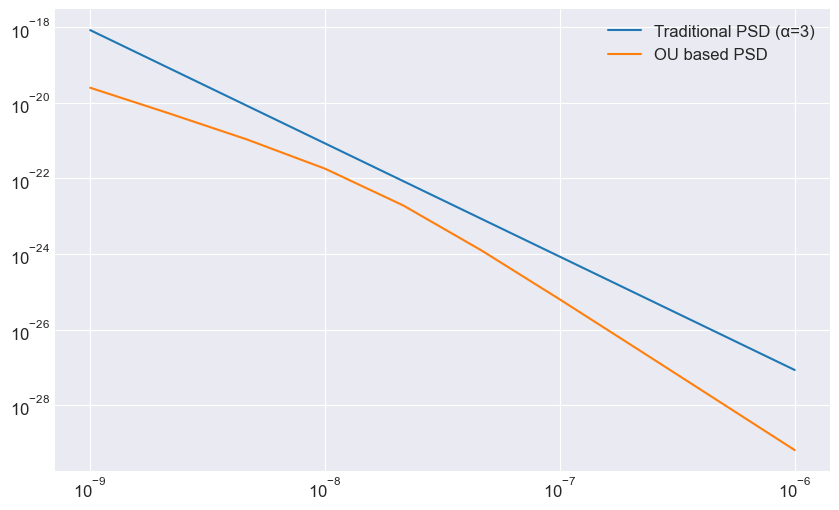

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatter
import matplotlib as mpl

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
mpl.rcParams['figure.figsize'] = [10, 6]
mpl.rcParams['font.size'] = 12


plt.loglog(f_range, psd_trad, label=f'Traditional PSD (α={alpha})')
plt.loglog(f_range, psd_ou, label=f'OU based PSD')
plt.legend()

In [ ]:



# Define frequency range (in Hz)
f_min = 1 / (10 * seconds_per_year)  # 0.1 cycles per decade
f_max = 10 / seconds_per_year  # 10 cycles per year
f = np.logspace(np.log10(f_min), np.log10(f_max), 1000)

# Parameters for traditional PSD

alpha_values = [2, 2.5, 3, 4]  # Different spectral indices to compare

# Parameters for our OU-based PSD
f0 = 1  # Reference frequency in Hz
gamma = 2 * np.pi / (1 * seconds_per_year)  # Corner frequency at 1 year^-1
fc = gamma / (2 * np.pi)  # Corner frequency
sigma = 1e-8  # Will be adjusted based on A to match amplitudes



# Function to match OU parameters to traditional PSD
def match_parameters(A, alpha, f_ref, f0, target_fc):
    """Find sigma and gamma to match traditional PSD with given alpha"""
    gamma = 2 * np.pi * target_fc
    
    # For matching at a specific frequency (we'll use f_ref)
    if alpha == 2:
        # In the low-frequency regime
        sigma_squared = (A**2 * (f0 * gamma)**2 * (2 * np.pi)**2) / (12 * np.pi**2) * seconds_per_year
    elif alpha == 4:
        # In the high-frequency regime
        sigma_squared = (A**2 * (f0 * gamma)**2 * (2 * np.pi)**2 * (f_ref/target_fc)**2) / (12 * np.pi**2) * seconds_per_year
    else:
        # For intermediate values, we'll match at f_ref
        trad_at_ref = traditional_psd(f_ref, A, alpha, f_ref)
        factor = f_ref**2 * (1 + (f_ref/target_fc)**2)
        sigma_squared = trad_at_ref * ((f0 * gamma)**2 * (2 * np.pi)**2) * factor
    
    return np.sqrt(sigma_squared), gamma

# Create plot
plt.figure(figsize=(12, 8))

# Plot traditional PSDs for different alpha values
for alpha in alpha_values:
    # Calculate matched parameters
    target_fc = f_ref  # Position corner at reference frequency
    sigma_matched, gamma_matched = match_parameters(A, alpha, f_ref, f0, target_fc)
    
    # Plot traditional PSD
    traditional = traditional_psd(f, A, alpha, f_ref)
    plt.loglog(f * seconds_per_year, traditional / seconds_per_year, 
               label=f'Traditional PSD (α={alpha})')
    
    # Plot matched OU-based PSD
    matched_ou = ou_based_psd(f, sigma_matched, gamma_matched, f0)
    plt.loglog(f * seconds_per_year, matched_ou / seconds_per_year, '--', 
               label=f'Matched OU PSD (α={alpha})')

# Enhance plot
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.xlabel('Frequency (cycles/year)')
plt.ylabel('PSD (yr³)')
plt.title('Comparison of Traditional and OU-based Power Spectral Densities')
plt.legend(fontsize=10)
plt.tight_layout()

# Add vertical line at corner frequency
plt.axvline(x=gamma/(2*np.pi) * seconds_per_year, color='black', linestyle=':', alpha=0.7,
           label='Corner Frequency')

# Add reference lines to show slopes
f_ref_idx = np.argmin(np.abs(f - f_ref))
ref_point = traditional_psd(f[f_ref_idx], A, 2, f_ref) / seconds_per_year
x_ref = f[f_ref_idx] * seconds_per_year

# Add slope reference lines
x_range = np.array([x_ref/5, x_ref*5])
plt.loglog(x_range, ref_point * (x_range/x_ref)**(-2), 'k:', alpha=0.5, label='f⁻² slope')
plt.loglog(x_range, ref_point * (x_range/x_ref)**(-4), 'k-.', alpha=0.5, label='f⁻⁴ slope')

plt.legend(fontsize=10, loc='lower left')
plt.xlim(f_min * seconds_per_year, f_max * seconds_per_year)

# Show plot
plt.savefig('psd_comparison.png', dpi=300)
plt.show()

# Now let's also plot a specific case to see how well we can match a given alpha
# For example, let's focus on alpha = 2.5 which is common in time standards

plt.figure(figsize=(10, 6))

alpha_focus = 2.5
# Try different corner frequencies to see which best matches alpha = 2.5
corner_fractions = [0.1, 0.5, 1.0, 2.0, 10.0]  # Fractions of f_ref

for frac in corner_fractions:
    target_fc = f_ref * frac
    sigma_matched, gamma_matched = match_parameters(A, alpha_focus, f_ref, f0, target_fc)
    
    # Plot traditional PSD
    traditional = traditional_psd(f, A, alpha_focus, f_ref)
    if frac == 1.0:  # Only plot traditional once
        plt.loglog(f * seconds_per_year, traditional / seconds_per_year, 'k-', 
                  linewidth=2, label=f'Traditional PSD (α={alpha_focus})')
    
    # Plot matched OU-based PSD
    matched_ou = ou_based_psd(f, sigma_matched, gamma_matched, f0)
    plt.loglog(f * seconds_per_year, matched_ou / seconds_per_year, '--', 
              label=f'OU PSD (fc = {frac:.1f}×f_ref)')
    
    # Add vertical line at this corner frequency
    plt.axvline(x=target_fc * seconds_per_year, linestyle=':', alpha=0.3)

plt.grid(True, which="both", ls="-", alpha=0.2)
plt.xlabel('Frequency (cycles/year)')
plt.ylabel('PSD (yr³)')
plt.title(f'Matching Traditional PSD (α={alpha_focus}) with Different Corner Frequencies')
plt.legend(fontsize=10)
plt.xlim(f_min * seconds_per_year, f_max * seconds_per_year)
plt.tight_layout()

# Show plot
plt.savefig('psd_matching_alpha25.png', dpi=300)
plt.show()